In [254]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
  sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [268]:
def load_trades(csv_path: str, start_date: str = "2022-04-01") -> pd.DataFrame:
    """
    Load and summarize trade data from CSV export.

    Args:
        csv_path: Path to the trades CSV.
        start_date: Ignore trades with entry timestamps before this date (UTC).

    Returns:
        DataFrame with columns [entry_time, exit_time, pnl, fees, total_pnl] that
        aggregates all legs belonging to the same trade. The total PnL is the sum
        of the P&L column minus the summed fees for the trade.
    """

    data = pd.read_csv(csv_path, header=0, skipinitialspace=True)
    if "Order Ids" in data.columns:
        data = data.drop(columns=["Order Ids"])

    for column in ("Entry Time", "Exit Time"):
        data[column] = pd.to_datetime(data[column], utc=True)

    cutoff = pd.Timestamp(start_date, tz="UTC")
    data = data[data["Entry Time"] >= cutoff].reset_index(drop=True)

    for column in ("Entry Time", "Exit Time"):
        data[column] = data[column].dt.tz_convert("America/New_York")

    grouped = (
        data.sort_values("Entry Time")
        .groupby(["Entry Time", "Exit Time"], as_index=False)
        .agg(pnl=("P&L", "sum"), fees=("Fees", "sum"))
    )

    grouped["total_pnl"] = grouped["pnl"] - grouped["fees"]
    grouped = grouped.rename(columns={"Entry Time": "entry_time", "Exit Time": "exit_time"})

    return grouped

In [255]:
initial_capital = 50000
trades = load_trades("../data/baseline_v1_trades_02_13_2026.csv")

In [256]:
df = trades.copy()
df['exit_time'] = pd.to_datetime(df['exit_time'])
df = df.sort_values('exit_time')
df['date'] = df['exit_time'].dt.date

daily = df.groupby('date')['total_pnl'].sum()
daily.index = pd.to_datetime(daily.index)

# NOTE: fill missing days
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='B')
daily = daily.reindex(full_idx, fill_value=0)

In [257]:
# NOTE: equity curve
# initial_capital = 50000
# equity = initial_capital + daily.cumsum()
# ax = equity.plot(figsize=(12, 4), title="Equity Curve", grid=True)
# NOTE: compute sharpe
# sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
# print(sharpe)

## Sharpe Sensitivity to Wrost Trades

In [258]:
df_sorted = trades.sort_values('total_pnl')

results = []

for i in range(len(df_sorted)):
    df = df_sorted.iloc[i:].copy()

    df['exit_time'] = pd.to_datetime(df['exit_time'])
    df = df.sort_values('exit_time')
    df['date'] = df['exit_time'].dt.date

    daily = df.groupby('date')['total_pnl'].sum()
    daily.index = pd.to_datetime(daily.index)

    # fill missing days
    full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='B')
    daily = daily.reindex(full_idx, fill_value=0)

    # equity + returns
    equity = initial_capital + daily.cumsum()
    returns = equity.pct_change().dropna()

    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

    results.append({
        'trades_removed': i,
        'sharpe': sharpe
    })

sr_removed_trades_df = pd.DataFrame(results)

In [271]:
sr_removed_trades_df.head(30)

,trades_removed,sharpe
0,0,-0.883546
1,1,-0.777127
2,2,-0.674355
3,3,-0.574490
4,4,-0.474803
5,5,-0.378947
6,6,-0.279189
7,7,-0.177039
8,8,-0.078928
9,9,0.020967


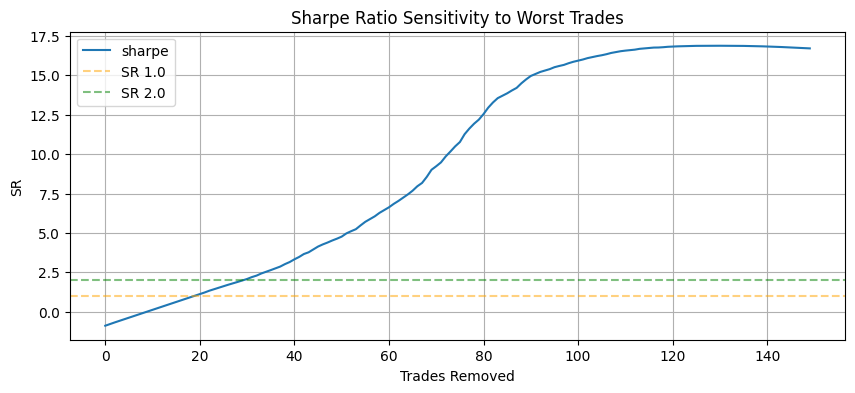

In [259]:
ax = sr_removed_trades_df['sharpe'][:150].plot(
    grid=True, 
    xlabel="Trades Removed", 
    ylabel="SR", 
    title="Sharpe Ratio Sensitivity to Worst Trades",
    figsize=(10, 4)
)
ax.axhline(1, linestyle='--', c='orange', label='SR 1.0', alpha=0.5)
ax.axhline(2, linestyle='--', c='green', label='SR 2.0', alpha=0.5)
ax.legend(loc='best')
plt.savefig("sharpe_sensitivity.png", dpi=300, bbox_inches='tight')

## Equity

In [260]:
def compute_equity(df):
    df = df.copy()
    df['exit_time'] = pd.to_datetime(df['exit_time'])
    df = df.sort_values('exit_time')
    df['date'] = df['exit_time'].dt.date

    daily = df.groupby('date')['total_pnl'].sum()
    daily.index = pd.to_datetime(daily.index)

    return daily

In [261]:
def get_normalized_equity(df, n_remove=0):
    if n_remove > 0:
        df = df.sort_values('total_pnl').iloc[n_remove:]

    daily = compute_equity(df)
    daily = daily.reindex(full_idx, fill_value=0)

    equity = initial_capital + daily.cumsum()
    equity_norm = equity / equity.iloc[0]

    return equity_norm

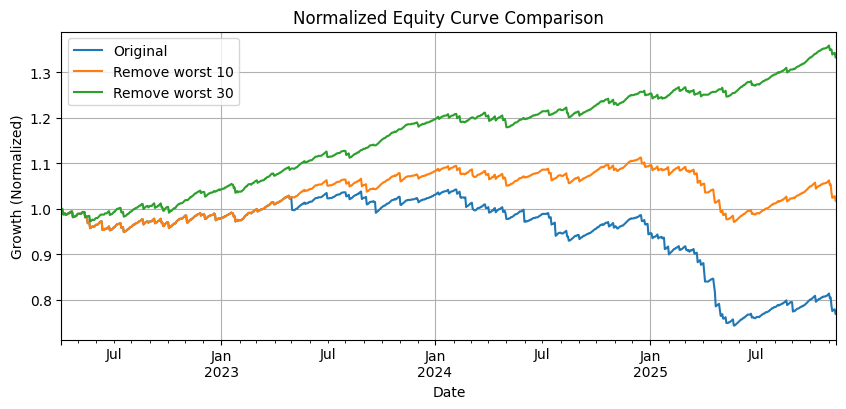

In [262]:
# --- base daily pnl ---
daily_full = compute_equity(trades)

# use same index for all
full_idx = pd.date_range(daily_full.index.min(), daily_full.index.max(), freq='B')
daily_full = daily_full.reindex(full_idx, fill_value=0)

# --- compute curves ---
eq_full = get_normalized_equity(trades, 0)
eq_10 = get_normalized_equity(trades, 10)
eq_30 = get_normalized_equity(trades, 30)

# --- plot ---
ax = eq_full.plot(figsize=(10, 4), label='Original', grid=True)
eq_10.plot(ax=ax, label='Remove worst 10')
eq_30.plot(ax=ax, label='Remove worst 30')

ax.set_title("Normalized Equity Curve Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (Normalized)")
ax.grid(True)
ax.legend()
plt.savefig("normalized_equity_curve.png", dpi=300, bbox_inches='tight')

## Drawdowns

In [263]:
for eq_curve in [eq_full, eq_10, eq_30]:
    # NOTE: get max and mean drawdown
    running_max = eq_curve.cummax()
    drawdown = (eq_curve - running_max) / running_max

    # NOTE: calc duration
    in_drawdown = drawdown < 0
    drawdown_groups = (in_drawdown != in_drawdown.shift()).cumsum()
    dd_df = pd.DataFrame({
        'drawdown': drawdown,
        'in_dd': in_drawdown,
        'group': drawdown_groups
    })

    # keep only drawdown periods
    dd_periods = dd_df[dd_df['in_dd']]

    # duration = number of days in each drawdown
    dd_durations = dd_periods.groupby('group').size()

    max_duration = dd_durations.max()
    avg_duration = dd_durations.mean()

    # NOTE: Report
    print('max dd: ', drawdown.min())
    print('mean dd: ', drawdown[drawdown < 0].mean())
    print("max duration (days):", max_duration)
    print("mean duration (days):", avg_duration)
    print('---')

max dd:  -0.28662579038129904
mean dd:  -0.07987351410461518
max duration (days): 463
mean duration (days): 99.88888888888889
---
max dd:  -0.1267663799759395
mean dd:  -0.03197035032695385
max duration (days): 245
mean duration (days): 48.94117647058823
---
max dd:  -0.02774559546162758
mean dd:  -0.008309564667322264
max duration (days): 75
mean duration (days): 16.054054054054053
---


In [265]:
def get_drawdown(df, n_remove=0):
    if n_remove > 0:
        df = df.sort_values('total_pnl').iloc[n_remove:]

    daily = compute_daily(df)
    daily = daily.reindex(full_idx, fill_value=0)

    equity = initial_capital + daily.cumsum()
    drawdown = (equity - equity.cummax()) / equity.cummax()

    return drawdown

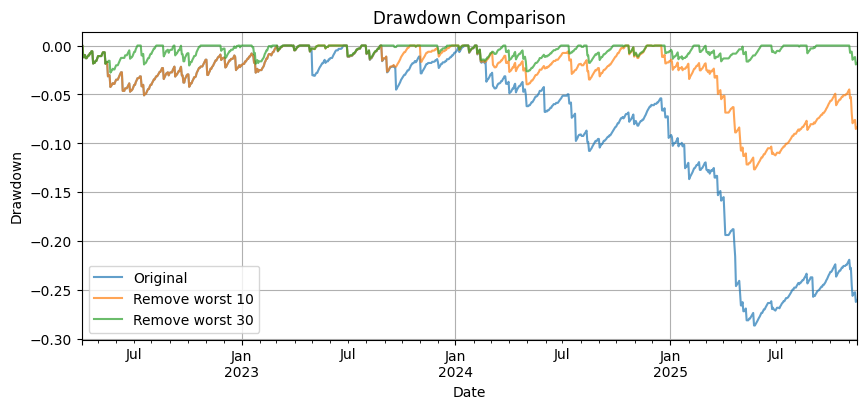

In [266]:
dd_full = get_drawdown(trades, 0)
dd_10 = get_drawdown(trades, 10)
dd_30 = get_drawdown(trades, 30)

ax = dd_full.plot(figsize=(10, 4), label='Original', alpha=0.7, grid=True)
dd_10.plot(ax=ax, label='Remove worst 10', alpha=0.7)
dd_30.plot(ax=ax, label='Remove worst 30', alpha=0.7)

ax.set_title("Drawdown Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()
plt.savefig("drawdowns.png", dpi=300, bbox_inches='tight')